In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:
conn = sqlite3.connect("data/bluestock_mf.db")

In [3]:
tables = pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

tables

NameError: name 'pd' is not defined

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
conn = sqlite3.connect("../bluestock_mf.db")

print("Database connected successfully!")

Database connected successfully!


In [7]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

tables

,name
0,dim_fund
1,dim_date
2,fact_nav
3,fact_transactions
4,sqlite_sequence
5,fact_performance
6,fact_aum
7,fact_sip_inflows
8,fact_category_inflows
9,fact_folio_count


In [8]:
nav = pd.read_sql("SELECT * FROM fact_nav", conn)

In [9]:
nav.head()

,amfi_code,date_id,nav
0,100016,2,520.4608
1,100016,3,515.0971
2,100016,4,521.7239
3,100016,5,515.7880
4,100016,6,515.1639


In [10]:
print(nav.columns.tolist())

['amfi_code', 'date_id', 'nav']


In [11]:
funds = pd.read_sql("SELECT * FROM dim_fund", conn)

In [12]:
funds.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100025,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,500,1000,Anil Bamboli,Low,DC02
2,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
3,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
4,101207,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03


In [13]:
dates = pd.read_sql("SELECT * FROM dim_date", conn)

dates.head()

,date_id,date,year,month,month_name,quarter
0,1,2022-01-01,2022,1,January,1
1,2,2022-01-03,2022,1,January,1
2,3,2022-01-04,2022,1,January,1
3,4,2022-01-05,2022,1,January,1
4,5,2022-01-06,2022,1,January,1


In [14]:
print(dates.columns.tolist())

['date_id', 'date', 'year', 'month', 'month_name', 'quarter']


In [15]:
nav = nav.merge(
    dates[['date_id', 'date']],
    on='date_id',
    how='left'
)

nav.head()

,amfi_code,date_id,nav,date
0,100016,2,520.4608,2022-01-03
1,100016,3,515.0971,2022-01-04
2,100016,4,521.7239,2022-01-05
3,100016,5,515.7880,2022-01-06
4,100016,6,515.1639,2022-01-07


In [16]:
nav['date'] = pd.to_datetime(nav['date'])

In [17]:
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

In [18]:
nav.head(10)

,amfi_code,date_id,nav,date
0,100016,2,520.4608,2022-01-03
1,100016,3,515.0971,2022-01-04
2,100016,4,521.7239,2022-01-05
3,100016,5,515.7880,2022-01-06
4,100016,6,515.1639,2022-01-07
5,100016,7,510.7136,2022-01-10
6,100016,8,513.5542,2022-01-11
7,100016,9,512.3195,2022-01-12
8,100016,10,510.2445,2022-01-13
9,100016,11,514.3636,2022-01-14


In [19]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [20]:
nav.head(10)

,amfi_code,date_id,nav,date,daily_return
0,100016,2,520.4608,2022-01-03,NaN
1,100016,3,515.0971,2022-01-04,-0.010306
2,100016,4,521.7239,2022-01-05,0.012865
3,100016,5,515.7880,2022-01-06,-0.011377
4,100016,6,515.1639,2022-01-07,-0.001210
5,100016,7,510.7136,2022-01-10,-0.008639
6,100016,8,513.5542,2022-01-11,0.005562
7,100016,9,512.3195,2022-01-12,-0.002404
8,100016,10,510.2445,2022-01-13,-0.004050
9,100016,11,514.3636,2022-01-14,0.008073


In [21]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

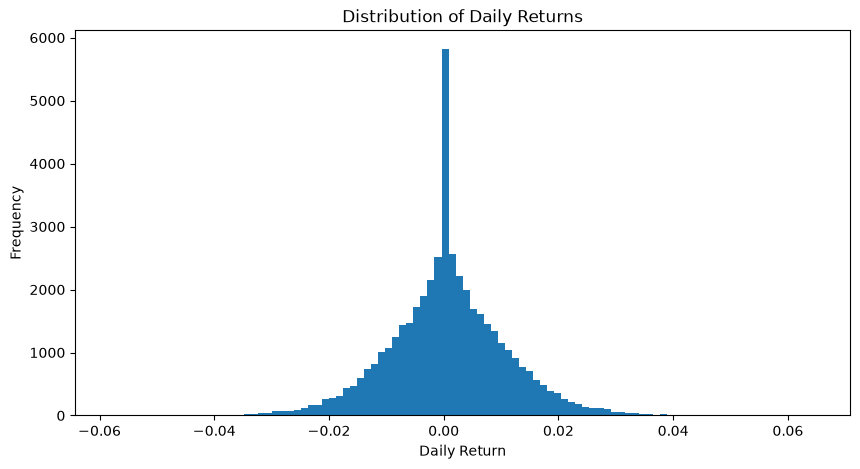

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(nav["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [23]:
cagr_data = (
    nav.groupby("amfi_code")
       .agg(
           start_date=("date", "min"),
           end_date=("date", "max"),
           start_nav=("nav", "first"),
           end_nav=("nav", "last")
       )
       .reset_index()
)

cagr_data.head()

,amfi_code,start_date,end_date,start_nav,end_nav
0,100016,2022-01-03,2026-05-29,520.4608,583.6113
1,100025,2022-01-03,2026-05-29,26.3169,31.8843
2,100033,2022-01-03,2026-05-29,107.3758,342.0072
3,101206,2022-01-03,2026-05-29,305.0996,773.2939
4,101207,2022-01-03,2026-05-29,38.5736,53.9836


In [24]:
years = (
    cagr_data["end_date"] - cagr_data["start_date"]
).dt.days / 365.25

cagr_data["cagr"] = (
    (cagr_data["end_nav"] / cagr_data["start_nav"]) ** (1 / years) - 1
)

In [25]:
cagr_data["cagr_pct"] = cagr_data["cagr"] * 100

cagr_data.head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,cagr,cagr_pct
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,0.026371,2.637074
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,0.044582,4.458210
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,0.301232,30.123153
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,0.235384,23.538361
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,0.079388,7.938765
5,101208,2022-01-03,2026-05-29,310.7415,410.1021,0.065090,6.509027
6,102885,2022-01-03,2026-05-29,89.8728,187.7797,0.182324,18.232379
7,102886,2022-01-03,2026-05-29,119.2905,125.5640,0.011717,1.171745
8,102887,2022-01-03,2026-05-29,191.0721,378.9657,0.168411,16.841120
9,118632,2022-01-03,2026-05-29,42.8339,110.5554,0.240495,24.049493


In [26]:
cagr_data.sort_values("cagr_pct", ascending=False).head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,cagr,cagr_pct
25,120505,2022-01-03,2026-05-29,135.8720,473.7640,0.328274,32.827406
21,119598,2022-01-03,2026-05-29,89.8738,309.2050,0.324235,32.423536
39,149324,2022-01-03,2026-05-29,81.6814,279.7511,0.322874,32.287440
36,148569,2022-01-03,2026-05-29,28.8620,97.7435,0.319495,31.949523
34,148567,2022-01-03,2026-05-29,70.2514,230.2708,0.309741,30.974108
30,120843,2022-01-03,2026-05-29,49.9131,163.2397,0.309075,30.907455
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,0.301232,30.123153
38,149323,2022-01-03,2026-05-29,78.4622,245.3651,0.295811,29.581087
16,119094,2022-01-03,2026-05-29,68.3023,203.8581,0.282144,28.214417
19,119551,2022-01-03,2026-05-29,54.3856,149.3216,0.258047,25.804686


In [27]:
top_10_cagr = (
    cagr_data
    .sort_values("cagr_pct", ascending=False)
    .head(10)
)

top_10_cagr = top_10_cagr.merge(
    funds[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

top_10_cagr[
    ['amfi_code', 'scheme_name', 'category', 'cagr_pct']
]

,amfi_code,scheme_name,category,cagr_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,32.827406
1,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,32.423536
2,149324,DSP Small Cap Fund - Regular - Growth,Equity,32.287440
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,31.949523
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,30.974108
5,120843,Kotak Flexicap Fund - Regular - Growth,Equity,30.907455
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,30.123153
7,149323,DSP Midcap Fund - Regular - Growth,Equity,29.581087
8,119094,Axis Midcap Fund - Regular - Growth,Equity,28.214417
9,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,25.804686


In [28]:
def calculate_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    actual_years = (
        period.iloc[-1]["date"] - period.iloc[0]["date"]
    ).days / 365.25

    return (end_nav / start_nav) ** (1 / actual_years) - 1

In [29]:
cagr_results = []

for fund_id, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")

    cagr_results.append({
        "amfi_code": fund_id,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

In [30]:
cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,0.026371
1,100025,0.037076,0.039155,0.044582
2,100033,0.532772,0.324340,0.301232
3,101206,0.479638,0.289602,0.235384
4,101207,-0.240003,-0.041515,0.079388


In [31]:
cagr_df[cagr_df["amfi_code"] == 101207]

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
4,101207,-0.240003,-0.041515,0.079388


In [32]:
rf_annual = 0.065
rf_daily = rf_annual / 252

print("Annual risk-free rate:", rf_annual)
print("Daily risk-free rate:", rf_daily)

Annual risk-free rate: 0.065
Daily risk-free rate: 0.00025793650793650796


In [33]:
sharpe_results = []

for fund_id, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    excess_returns = returns - rf_daily

    sharpe = (
        excess_returns.mean() /
        excess_returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund_id,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [34]:
sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

sharpe_df.head()

,amfi_code,sharpe_ratio,sharpe_rank
0,100016,-0.201517,35.0
1,100025,-0.567095,39.0
2,100033,1.093699,7.0
3,101206,1.027213,9.0
4,101207,0.162661,28.0


In [35]:
sortino_results = []

for fund_id, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    excess_returns = returns - rf_daily

    downside_returns = excess_returns[excess_returns < 0]

    downside_std = downside_returns.std()

    sortino = (
        excess_returns.mean() /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund_id,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.348196
1,100025,-0.915371
2,100033,1.823824
3,101206,1.785592
4,101207,0.274615


In [39]:
benchmark = pd.read_sql(
    "SELECT * FROM fact_benchmark_indices",
    conn
)

print(benchmark.columns.tolist())
benchmark.head()

['date_id', 'index_name', 'close_value']


,date_id,index_name,close_value
0,2,NIFTY50,17492.79
1,3,NIFTY50,17689.64
2,4,NIFTY50,17835.05
3,5,NIFTY50,17878.51
4,6,NIFTY50,17759.15


In [40]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date_id,index_name,close_value
1150,2,NIFTY100,17778.24
1151,3,NIFTY100,17537.52
1152,4,NIFTY100,17607.73
1153,5,NIFTY100,17556.05
1154,6,NIFTY100,17664.02


In [41]:
nifty100["index_name"].value_counts()

index_name
NIFTY100    1150
Name: count, dtype: int64

In [42]:
nifty100 = nifty100.merge(
    dates[['date_id', 'date']],
    on='date_id',
    how='left'
)

nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value'].pct_change()
)

nifty100.head()

,date_id,index_name,close_value,date,benchmark_return
0,2,NIFTY100,17778.24,2022-01-03,NaN
1,3,NIFTY100,17537.52,2022-01-04,-0.013540
2,4,NIFTY100,17607.73,2022-01-05,0.004003
3,5,NIFTY100,17556.05,2022-01-06,-0.002935
4,6,NIFTY100,17664.02,2022-01-07,0.006150


In [43]:
merged = nav.merge(
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

print("Merged rows:", len(merged))
merged.head()

Merged rows: 46000


,amfi_code,date_id,nav,date,daily_return,benchmark_return
0,100016,2,520.4608,2022-01-03,NaN,NaN
1,100016,3,515.0971,2022-01-04,-0.010306,-0.013540
2,100016,4,521.7239,2022-01-05,0.012865,0.004003
3,100016,5,515.7880,2022-01-06,-0.011377,-0.002935
4,100016,6,515.1639,2022-01-07,-0.001210,0.006150


In [44]:
alpha_beta_results = []

for fund_id, group in merged.groupby("amfi_code"):

    group = group.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(group) < 2:
        continue

    result = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta_results.append({
        "amfi_code": fund_id,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [45]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [46]:
drawdown_results = []

for fund_id, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV till that date
    group["running_max"] = group["nav"].cummax()

    # Drawdown calculation
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Date of maximum drawdown
    min_idx = group["drawdown"].idxmin()

    drawdown_results.append({
        "amfi_code": fund_id,
        "max_drawdown": group["drawdown"].min(),
        "drawdown_date": group.loc[min_idx, "date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown,drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [47]:
drawdown_df.to_csv(
    "../data/processed/drawdown.csv",
    index=False
)

print("drawdown.csv saved successfully!")

drawdown.csv saved successfully!


In [48]:
drawdown_periods = []

for fund_id, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Worst drawdown / trough
    trough_idx = group["drawdown"].idxmin()

    # NAV at peak before the trough
    peak_nav = group.loc[trough_idx, "running_max"]

    # Find peak date
    peak_rows = group[
        group["nav"] == peak_nav
    ]

    peak_date = peak_rows.iloc[-1]["date"]

    # Trough date
    trough_date = group.loc[trough_idx, "date"]

    drawdown_periods.append({
        "amfi_code": fund_id,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "max_drawdown": group["drawdown"].min()
    })

drawdown_period_df = pd.DataFrame(drawdown_periods)

drawdown_period_df.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [49]:
drawdown_period_df.to_csv(
    "../data/processed/drawdown_period.csv",
    index=False
)

print("drawdown_period.csv saved successfully!")

drawdown_period.csv saved successfully!


In [51]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [52]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
    .merge(
        funds[["amfi_code", "expense_ratio_pct"]],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sharpe_rank,alpha,beta,max_drawdown,drawdown_date,expense_ratio_pct
0,100016,-0.022258,0.012924,0.026371,-0.201517,35.0,0.037476,-0.058268,-0.247344,2022-09-15,1.55
1,100025,0.037076,0.039155,0.044582,-0.567095,39.0,0.042818,0.001158,-0.043083,2023-07-28,0.56
2,100033,0.532772,0.324340,0.301232,1.093699,7.0,0.271954,0.005104,-0.162172,2022-05-12,1.38
3,101206,0.479638,0.289602,0.235384,1.027213,9.0,0.213998,0.021086,-0.112916,2023-07-05,1.60
4,101207,-0.240003,-0.041515,0.079388,0.162661,28.0,0.108971,-0.065289,-0.354469,2026-05-11,1.53


In [53]:
scorecard["return_score"] = (
    scorecard["cagr_3yr"].rank(pct=True) * 100
)

scorecard[[
    "amfi_code",
    "cagr_3yr",
    "return_score"
]].head()

,amfi_code,cagr_3yr,return_score
0,100016,0.012924,15.0
1,100025,0.039155,17.5
2,100033,0.324340,92.5
3,101206,0.289602,80.0
4,101207,-0.041515,5.0


In [54]:
scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"].rank(pct=True) * 100
)

scorecard[[
    "amfi_code",
    "sharpe_ratio",
    "sharpe_score"
]].head()

,amfi_code,sharpe_ratio,sharpe_score
0,100016,-0.201517,15.0
1,100025,-0.567095,5.0
2,100033,1.093699,85.0
3,101206,1.027213,80.0
4,101207,0.162661,32.5


In [55]:
scorecard["alpha_score"] = (
    scorecard["alpha"].rank(pct=True) * 100
)

scorecard[[
    "amfi_code",
    "alpha",
    "alpha_score"
]].head()

,amfi_code,alpha,alpha_score
0,100016,0.037476,5.0
1,100025,0.042818,7.5
2,100033,0.271954,87.5
3,101206,0.213998,72.5
4,101207,0.108971,35.0


In [56]:
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(pct=True, ascending=False) * 100
)

scorecard[[
    "amfi_code",
    "expense_ratio_pct",
    "expense_score"
]].head()

,amfi_code,expense_ratio_pct,expense_score
0,100016,1.55,22.50
1,100025,0.56,97.50
2,100033,1.38,60.00
3,101206,1.60,11.25
4,101207,1.53,31.25


In [57]:
scorecard["drawdown_score"] = (
    scorecard["max_drawdown"]
    .rank(pct=True) * 100
)

scorecard[[
    "amfi_code",
    "max_drawdown",
    "drawdown_score"
]].head()

,amfi_code,max_drawdown,drawdown_score
0,100016,-0.247344,17.5
1,100025,-0.043083,92.5
2,100033,-0.162172,52.5
3,101206,-0.112916,80.0
4,101207,-0.354469,7.5


In [58]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_score"] +
    0.25 * scorecard["sharpe_score"] +
    0.20 * scorecard["alpha_score"] +
    0.15 * scorecard["expense_score"] +
    0.10 * scorecard["drawdown_score"]
)

scorecard[[
    "amfi_code",
    "fund_score"
]].head()

,amfi_code,fund_score
0,100016,14.3750
1,100025,31.8750
2,100033,80.7500
3,101206,68.1875
4,101207,22.0625


In [59]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard["overall_rank"] = range(
    1, len(scorecard) + 1
)

scorecard[[
    "overall_rank",
    "amfi_code",
    "fund_score"
]].head(10)

,overall_rank,amfi_code,fund_score
34,1,148567,86.2500
25,2,120505,82.2500
30,3,120843,82.0000
2,4,100033,80.7500
24,5,120504,80.0000
16,6,119094,77.0000
19,7,119551,74.8125
36,8,148569,73.6875
3,9,101206,68.1875
21,10,119598,67.3750


In [60]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [61]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[148567, 120505, 120843, 100033, 120504]

In [62]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

three_year_nav = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5))
].copy()

print("Start date:", start_date)
print("End date:", end_date)
print("Rows:", len(three_year_nav))

Start date: 2023-05-29 00:00:00
End date: 2026-05-29 00:00:00
Rows: 3925


In [63]:
three_year_nav["indexed_nav"] = (
    three_year_nav
    .groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

three_year_nav[
    ["date", "amfi_code", "nav", "indexed_nav"]
].head(10)

,date,amfi_code,nav,indexed_nav
2665,2023-05-29,100033,147.2155,100.000000
2666,2023-05-30,100033,147.2007,99.989947
2667,2023-05-31,100033,147.4640,100.168800
2668,2023-06-01,100033,146.5954,99.578781
2669,2023-06-02,100033,145.8015,99.039503
2670,2023-06-05,100033,146.4025,99.447748
2671,2023-06-06,100033,148.1654,100.645245
2672,2023-06-07,100033,147.2075,99.994566
2673,2023-06-08,100033,145.7830,99.026937
2674,2023-06-09,100033,146.9565,99.824067


In [64]:
nifty100_3y = nifty100[
    nifty100["date"] >= start_date
].copy()

nifty100_3y["indexed"] = (
    nifty100_3y["close_value"] /
    nifty100_3y["close_value"].iloc[0] * 100
)

nifty100_3y[
    ["date", "close_value", "indexed"]
].head()

,date,close_value,indexed
365,2023-05-29,15324.41,100.000000
366,2023-05-30,15299.69,99.838689
367,2023-05-31,15248.41,99.504059
368,2023-06-01,15139.50,98.793363
369,2023-06-02,15194.66,99.153312


In [65]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.merge(
    dates[["date_id", "date"]],
    on="date_id",
    how="left"
)

nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty50 = nifty50.sort_values("date")

print("Nifty 50 rows:", len(nifty50))
print(nifty50.head())

Nifty 50 rows: 1150
   date_id index_name  close_value       date
0        2    NIFTY50     17492.79 2022-01-03
1        3    NIFTY50     17689.64 2022-01-04
2        4    NIFTY50     17835.05 2022-01-05
3        5    NIFTY50     17878.51 2022-01-06
4        6    NIFTY50     17759.15 2022-01-07


In [66]:
nifty50_3y = nifty50[
    nifty50["date"] >= start_date
].copy()

nifty50_3y["indexed"] = (
    nifty50_3y["close_value"] /
    nifty50_3y["close_value"].iloc[0] * 100
)

nifty50_3y[
    ["date", "close_value", "indexed"]
].head()

,date,close_value,indexed
365,2023-05-29,24688.69,100.000000
366,2023-05-30,24558.17,99.471337
367,2023-05-31,24476.07,99.138796
368,2023-06-01,24375.89,98.733023
369,2023-06-02,24398.93,98.826345


In [67]:
# Top 5 funds ko wide format mein convert karo
funds_indexed = three_year_nav.pivot(
    index="date",
    columns="amfi_code",
    values="indexed_nav"
)

# Nifty 50 and Nifty 100
comparison = funds_indexed.copy()

comparison["NIFTY50"] = (
    nifty50_3y.set_index("date")["indexed"]
)

comparison["NIFTY100"] = (
    nifty100_3y.set_index("date")["indexed"]
)

# Sort by date
comparison = comparison.sort_index()

comparison.head()

amfi_code,100033,120504,120505,120843,148567,NIFTY50,NIFTY100
date,,,,,,,
2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-05-30,99.989947,98.526178,100.593434,99.747805,99.638666,99.471337,99.838689
2023-05-31,100.168800,99.516215,101.289799,99.746072,100.122465,99.138796,99.504059
2023-06-01,99.578781,99.268321,100.812724,98.623056,100.351721,98.733023,98.793363
2023-06-02,99.039503,99.097519,103.431495,100.117700,100.249319,98.826345,99.153312


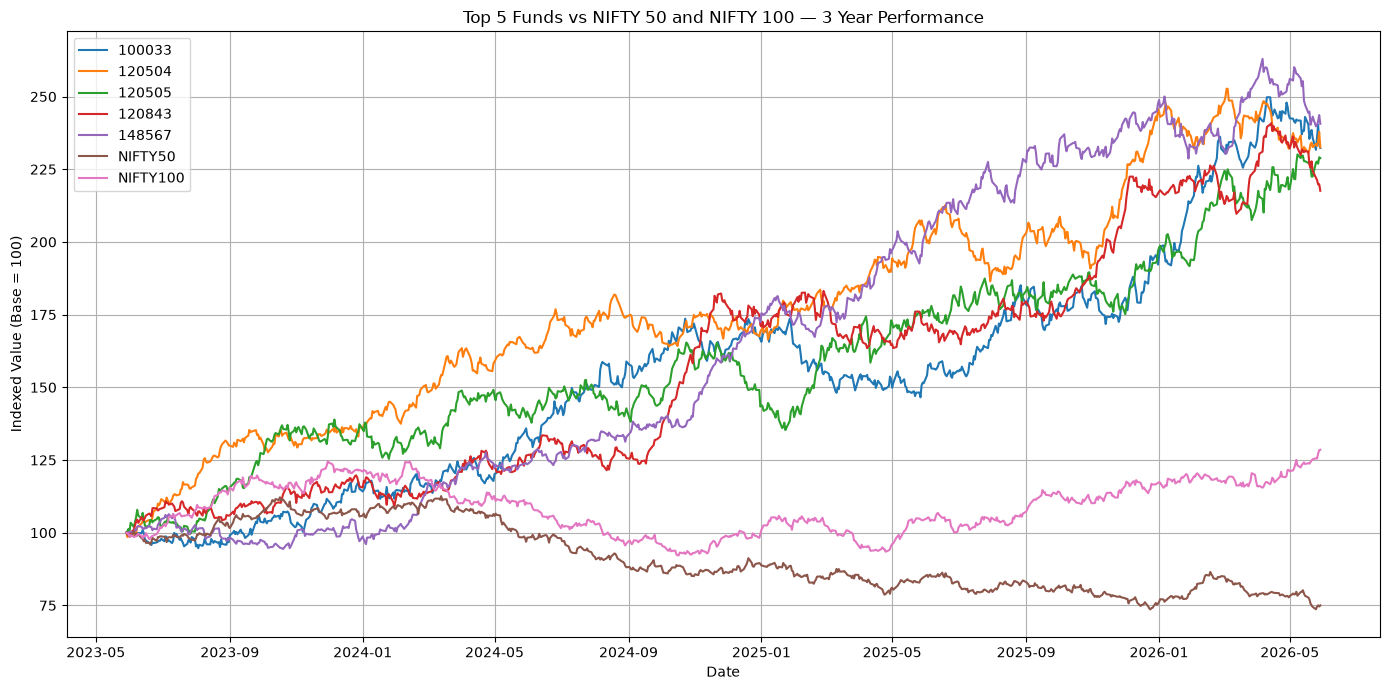

In [68]:
plt.figure(figsize=(14, 7))

for col in comparison.columns:
    plt.plot(
        comparison.index,
        comparison[col],
        label=str(col)
    )

plt.title("Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3 Year Performance")
plt.xlabel("Date")
plt.ylabel("Indexed Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

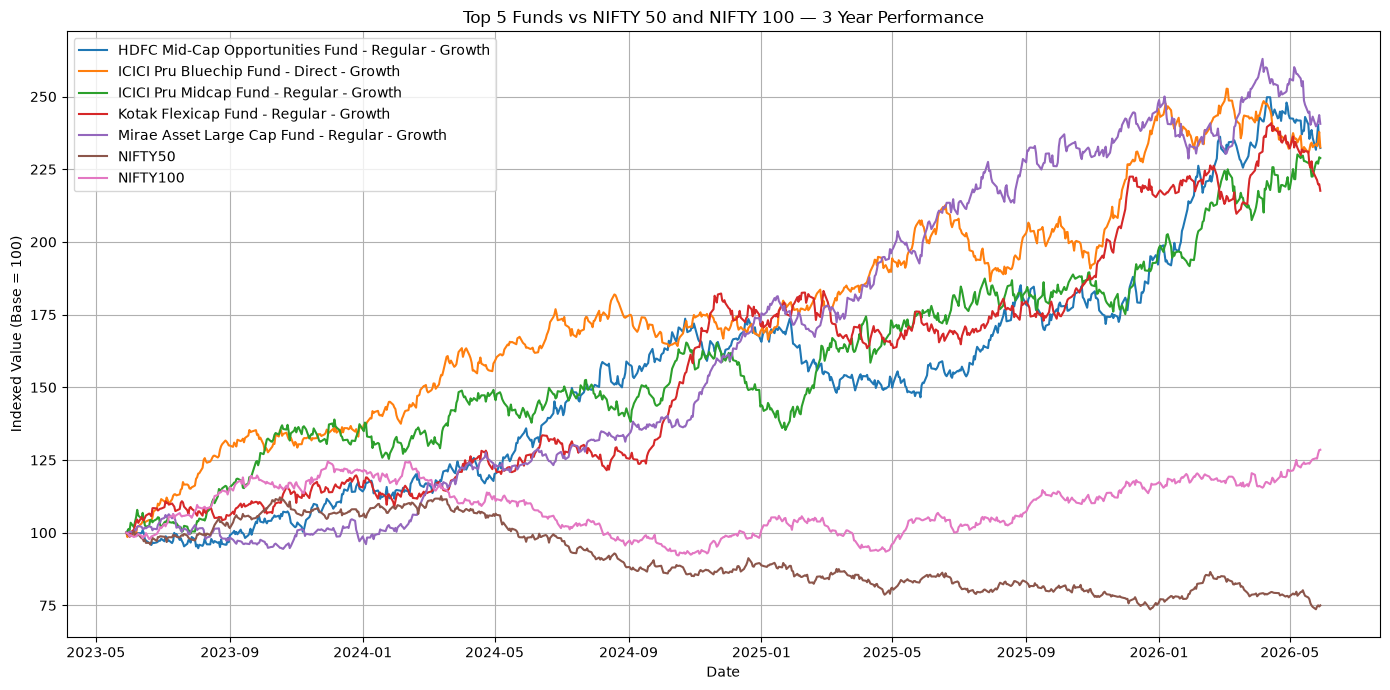

Benchmark comparison chart saved successfully!


In [69]:
# Map AMFI codes to fund names
fund_name_map = funds.set_index("amfi_code")["scheme_name"].to_dict()

# Rename fund columns
plot_data = comparison.rename(
    columns=fund_name_map
)

plt.figure(figsize=(14, 7))

for col in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[col],
        label=str(col)
    )

plt.title("Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3 Year Performance")
plt.xlabel("Date")
plt.ylabel("Indexed Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save chart
plt.savefig(
    "../reports/top5_vs_benchmarks_3y.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark comparison chart saved successfully!")

In [71]:
"data/processed/benchmark_comparison.png"

'data/processed/benchmark_comparison.png'

In [72]:
import os

print(os.getcwd())

c:\Users\anjli\Downloads\mutual-fund-analytics\notebooks


In [73]:
plt.savefig(
    "../data/processed/benchmark_comparison.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [74]:
print("Top 5:", top5)
print("Three year rows:", len(three_year_nav))
print("Columns:", three_year_nav.columns.tolist())

Top 5: [148567, 120505, 120843, 100033, 120504]
Three year rows: 3925
Columns: ['amfi_code', 'date_id', 'nav', 'date', 'daily_return', 'indexed_nav']


In [75]:
for fund_id in top5:
    data = three_year_nav[
        three_year_nav["amfi_code"] == fund_id
    ]
    print(fund_id, "rows =", len(data))

148567 rows = 785
120505 rows = 785
120843 rows = 785
100033 rows = 785
120504 rows = 785


In [76]:
print("Nifty 100 rows:", len(nifty100_3y))
print("Nifty 100 columns:", nifty100_3y.columns.tolist())

print("Nifty 50 rows:", len(nifty50_3y))
print("Nifty 50 columns:", nifty50_3y.columns.tolist())

Nifty 100 rows: 785
Nifty 100 columns: ['date_id', 'index_name', 'close_value', 'date', 'benchmark_return', 'indexed']
Nifty 50 rows: 785
Nifty 50 columns: ['date_id', 'index_name', 'close_value', 'date', 'indexed']


In [77]:
print(nifty100_3y.head())
print(nifty50_3y.head())

     date_id index_name  close_value       date  benchmark_return     indexed
365      371   NIFTY100     15324.41 2023-05-29          0.000667  100.000000
366      372   NIFTY100     15299.69 2023-05-30         -0.001613   99.838689
367      373   NIFTY100     15248.41 2023-05-31         -0.003352   99.504059
368      374   NIFTY100     15139.50 2023-06-01         -0.007142   98.793363
369      375   NIFTY100     15194.66 2023-06-02          0.003643   99.153312
     date_id index_name  close_value       date     indexed
365      371    NIFTY50     24688.69 2023-05-29  100.000000
366      372    NIFTY50     24558.17 2023-05-30   99.471337
367      373    NIFTY50     24476.07 2023-05-31   99.138796
368      374    NIFTY50     24375.89 2023-06-01   98.733023
369      375    NIFTY50     24398.93 2023-06-02   98.826345


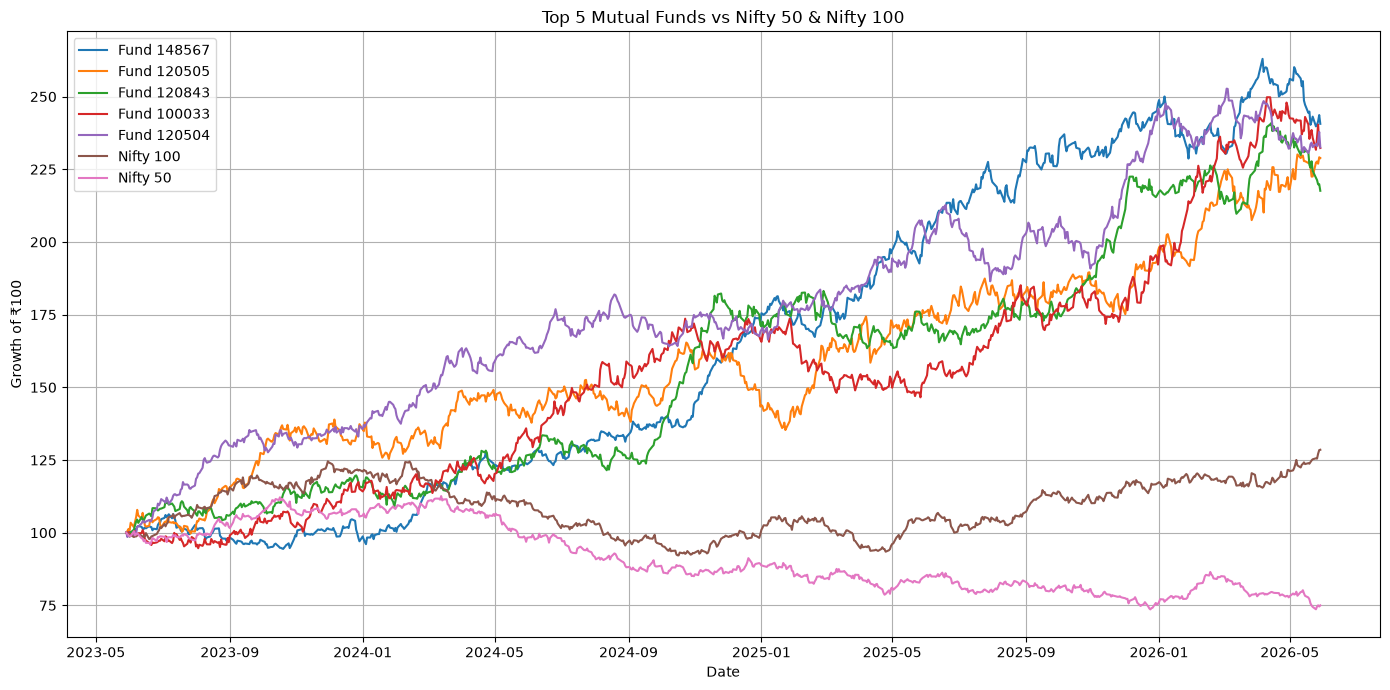

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for fund_id in top5:
    data = three_year_nav[
        three_year_nav["amfi_code"] == fund_id
    ]

    plt.plot(
        data["date"],
        data["indexed_nav"],
        label=f"Fund {fund_id}"
    )

plt.plot(
    nifty100_3y["date"],
    nifty100_3y["indexed"],
    label="Nifty 100"
)

plt.plot(
    nifty50_3y["date"],
    nifty50_3y["indexed"],
    label="Nifty 50"
)

plt.title("Top 5 Mutual Funds vs Nifty 50 & Nifty 100")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../data/processed/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [79]:
import numpy as np

nifty50["return"] = nifty50["close_value"].pct_change()

In [80]:
nifty100["return"] = nifty100["close_value"].pct_change()

In [81]:
tracking_results = []

for fund_id in top5:

    fund_data = nav[
        nav["amfi_code"] == fund_id
    ][["date", "daily_return"]]

    temp = fund_data.merge(
        nifty50[["date", "return"]],
        on="date",
        how="inner"
    )

    tracking_error_50 = (
        temp["daily_return"] - temp["return"]
    ).std() * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund_id,
        "tracking_error_nifty50": tracking_error_50
    })

tracking_results

[{'amfi_code': 148567,
  'tracking_error_nifty50': np.float64(0.19399579209820508)},
 {'amfi_code': 120505,
  'tracking_error_nifty50': np.float64(0.23312357538323944)},
 {'amfi_code': 120843,
  'tracking_error_nifty50': np.float64(0.20514776699717427)},
 {'amfi_code': 100033,
  'tracking_error_nifty50': np.float64(0.2297551098545287)},
 {'amfi_code': 120504,
  'tracking_error_nifty50': np.float64(0.19137581549582713)}]

In [82]:
tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,tracking_error_nifty50
0,148567,0.193996
1,120505,0.233124
2,120843,0.205148
3,100033,0.229755
4,120504,0.191376


In [83]:
print(nav["date"].dtype)
print(nifty50["date"].dtype)

datetime64[us]
datetime64[us]


In [84]:
tracking_results = []

for fund_id in top5:

    fund_data = nav[
        nav["amfi_code"] == fund_id
    ][["date", "daily_return"]]

    # Nifty 50
    temp50 = fund_data.merge(
        nifty50[["date", "return"]],
        on="date",
        how="inner"
    )

    tracking_error_50 = (
        temp50["daily_return"] - temp50["return"]
    ).std() * np.sqrt(252)

    # Nifty 100
    temp100 = fund_data.merge(
        nifty100[["date", "return"]],
        on="date",
        how="inner"
    )

    tracking_error_100 = (
        temp100["daily_return"] - temp100["return"]
    ).std() * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund_id,
        "tracking_error_nifty50": tracking_error_50,
        "tracking_error_nifty100": tracking_error_100
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,tracking_error_nifty50,tracking_error_nifty100
0,148567,0.193996,0.189664
1,120505,0.233124,0.231968
2,120843,0.205148,0.206425
3,100033,0.229755,0.228699
4,120504,0.191376,0.191587


In [85]:
tracking_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)